# CRC Mutation Clustering: Recovering Molecular Subtypes from Somatic Mutation Profiles

**Author:** Alexander Hannah, PhD  
**Data:** TCGA Colorectal Adenocarcinoma PanCancer Atlas (cBioPortal, n=528)  
**GitHub:** https://github.com/hannahas/crc-mutation-clustering

---

## Overview

Colorectal cancer (CRC) is not one disease — it is at least four molecularly distinct 
subtypes with different mutation profiles, clinical behaviors, and responses to treatment:

| Subtype | Description | Avg. Mutations |
|---|---|---|
| **CIN** | Chromosomal instability, APC/TP53-driven | ~56 |
| **MSI** | Mismatch repair deficiency, hypermutated | ~553 |
| **GS** | Genomically stable, early stage | ~58 |
| **POLE** | Polymerase epsilon mutated, ultra-hypermutated | ~1,708 |

This project asks: **can unsupervised clustering of somatic mutation profiles recover 
these known subtypes — and do the resulting clusters predict clinical outcomes like 
tumor stage and survival?**

The answer is yes — with important nuances about what the clustering adds beyond 
what the raw mutation data already tells you.

## The Data

All data was fetched programmatically from the cBioPortal REST API — no manual 
downloads required. The dataset is the TCGA Colorectal Adenocarcinoma PanCancer 
Atlas, one of the most comprehensive and well-characterized CRC genomic datasets 
available.

The raw data consists of three components:

**1. Somatic mutation records** — 208,739 individual mutations across 528 patients, 
each recording which gene was mutated, what type of mutation it was, and the variant 
allele frequency. These were pivoted into a binary matrix: 1 if a gene is mutated in 
a patient, 0 if not.

**2. Clinical data** — 42 attributes per patient including molecular subtype, AJCC 
tumor stage, overall survival, and disease-free survival.

**3. Mutation matrix** — 528 patients × 20,638 genes. Most genes are mutated in only 
one or two patients and carry no meaningful signal. For clustering, we filtered to the 
top 100 most frequently mutated genes — those appearing in at least 3% of patients.

The key biological variable is **molecular subtype**, which serves as our ground truth 
for evaluating whether the unsupervised clustering recovered real biological structure.

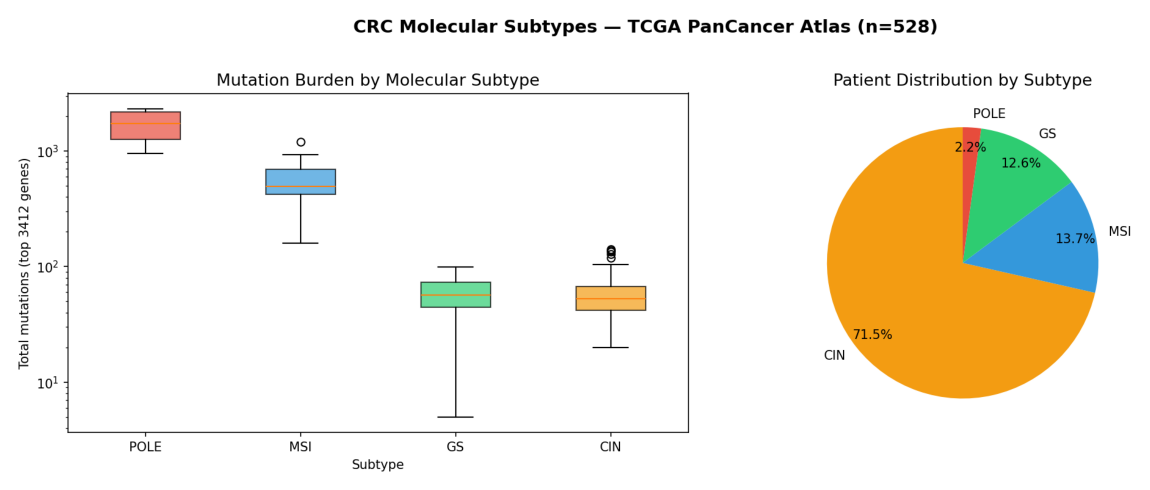

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import warnings
warnings.filterwarnings('ignore')

# Load data
clinical = pd.read_csv('../data/clinical.csv')
matrix = pd.read_csv('../data/mutation_matrix.csv', index_col=0)

# Display the subtype overview figure generated in the analysis notebook
img = mpimg.imread('../data/subtype_overview.png')
fig, ax = plt.subplots(figsize=(14, 5))
ax.imshow(img)
ax.axis('off')
plt.tight_layout()
plt.show()

### What this tells us

The most striking feature of CRC molecular subtypes is the dramatic difference in 
mutation burden — spanning nearly four orders of magnitude from CIN to POLE.

**POLE tumors (red)** average 1,708 mutations per patient. A defect in the DNA 
polymerase proofreading machinery causes mutations to accumulate at an extreme rate. 
These tumors are rare (2.2% of patients) but highly immunogenic and generally respond 
well to immunotherapy.

**MSI tumors (blue)** average 553 mutations per patient. Mismatch repair deficiency 
allows replication errors to persist, producing a hypermutated phenotype. MSI status 
is now an FDA-approved biomarker for immunotherapy eligibility across all solid tumors.

**GS (green) and CIN (orange)** both average ~57 mutations — nearly identical mutation 
burdens despite being molecularly distinct subtypes. GS tumors are genomically stable 
with few copy number changes; CIN tumors are driven by chromosomal instability with 
frequent APC and TP53 mutations. This similarity in mutation burden is important — it 
means mutation burden alone cannot distinguish these two subtypes.

CIN dominates the cohort at 71.5% of patients, reflecting its status as the most 
common CRC molecular subtype in Western populations.

## The Mutation Matrix

Before clustering, it helps to visualize the raw data directly. Each row below is a 
patient, each column is one of the top 50 most frequently mutated genes, and each cell 
is blue if that gene is mutated in that patient and white if not. Patients are sorted 
by molecular subtype.

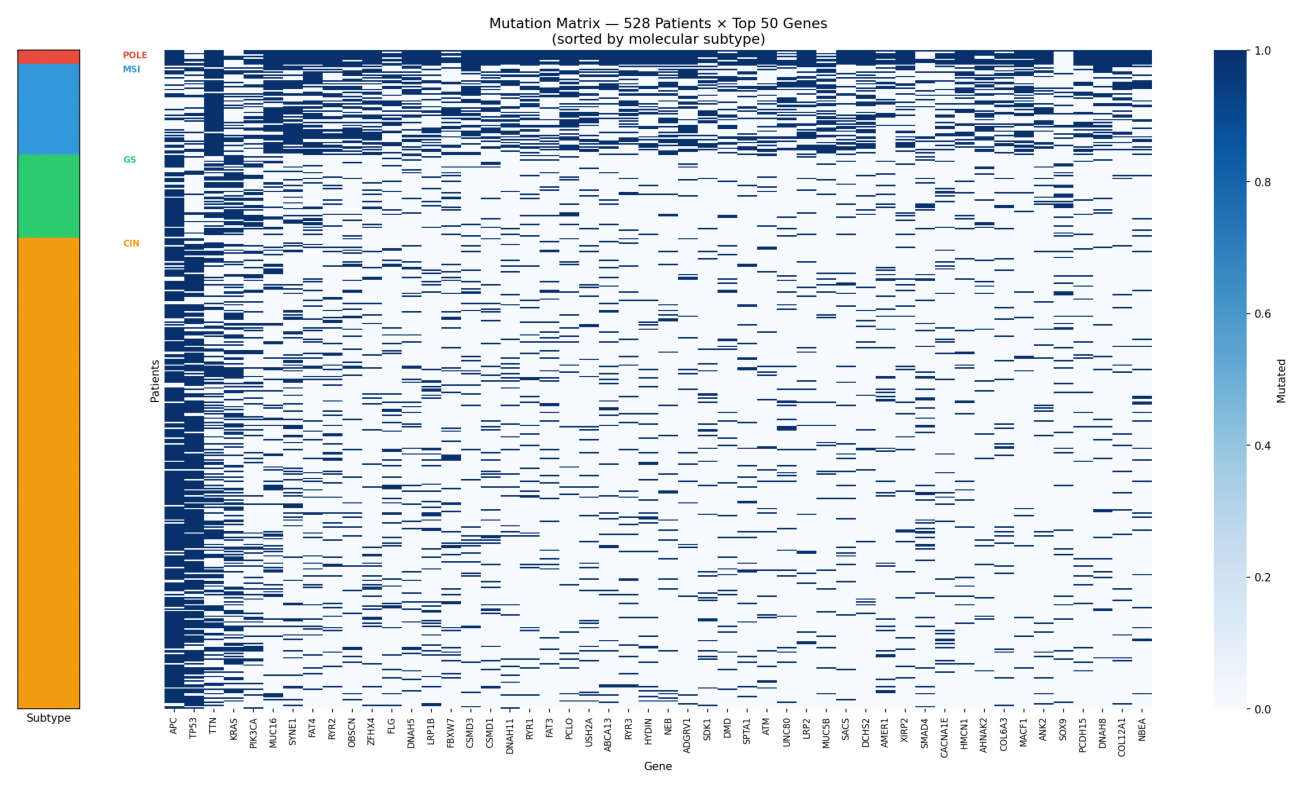

In [3]:
img = mpimg.imread('../data/mutation_heatmap_sorted.png')
fig, ax = plt.subplots(figsize=(16, 8))
ax.imshow(img)
ax.axis('off')
plt.tight_layout()
plt.show()

### What this tells us

Even before any clustering, the mutation matrix reveals clear visual structure 
that maps directly onto the known molecular subtypes.

**POLE (red, top ~10 rows)** — almost entirely dark blue across all genes. Every 
patient has mutations in nearly every gene shown. The ultra-hypermutation signature 
is unmistakable and visually separates this group immediately.

**MSI (blue, next ~63 rows)** — heavily mutated, especially in large genes like TTN, 
MUC16, and SYNE1. These are not driver mutations — they are passenger mutations that 
accumulate in large genes simply because larger genes present a bigger mutational 
target. The density clearly exceeds GS and CIN.

**GS (green, ~58 rows)** — sparse. APC and TP53 appear occasionally but most genes 
are white. Low mutation burden as expected for a genomically stable subtype.

**CIN (orange, bottom ~328 rows)** — similarly sparse to GS, but with a consistent 
dark band in the APC and TP53 columns on the far left. This is the canonical 
APC → TP53 → KRAS driver mutation sequence that characterizes the chromosomal 
instability pathway in CRC.

This visualization makes an important point: **a significant amount of subtype signal 
is already visible in the raw mutation data.** The question for the clustering analysis 
is whether it can recover this structure automatically — and whether it adds anything 
beyond what mutation burden alone would tell you.

## Dimensionality Reduction with PCA

The mutation matrix has 100 gene columns — too many to cluster directly without 
noise overwhelming the signal. Principal Component Analysis (PCA) compresses this 
into a smaller set of components that capture the most meaningful variation across 
patients.

### What PCA is doing

Each patient starts as a vector of 100 binary values (mutated or not per gene). PCA 
finds new axes — principal components — that are linear combinations of those 100 
genes, ordered by how much patient-to-patient variation they explain. The first 
component (PC1) captures the single most important axis of variation; PC2 captures 
the next most important, and so on.

Critically, PC scores are not binary — they are continuous values. A patient with a 
high PC1 score is very different from a patient with a low PC1 score along that axis. 
In our dataset, PC1 turns out to be essentially a **mutation burden axis**: patients 
with many mutations score high, patients with few mutations score low.

### Why PCA is more powerful than individual genes

A clinician can note that a patient has APC and TP53 mutations. But synthesizing 
patterns across 100 genes simultaneously is impossible without dimensionality 
reduction. PCA captures combinations of co-occurring mutations — entire biological 
pathways — in a single component. This is richer information than any single gene 
alone, and more statistically stable because it isn't dependent on any one gene 
being mutated.

### Results

50 principal components were retained, explaining 79.5% of the total variance in 
mutation profiles. The breakdown of the top components is revealing:

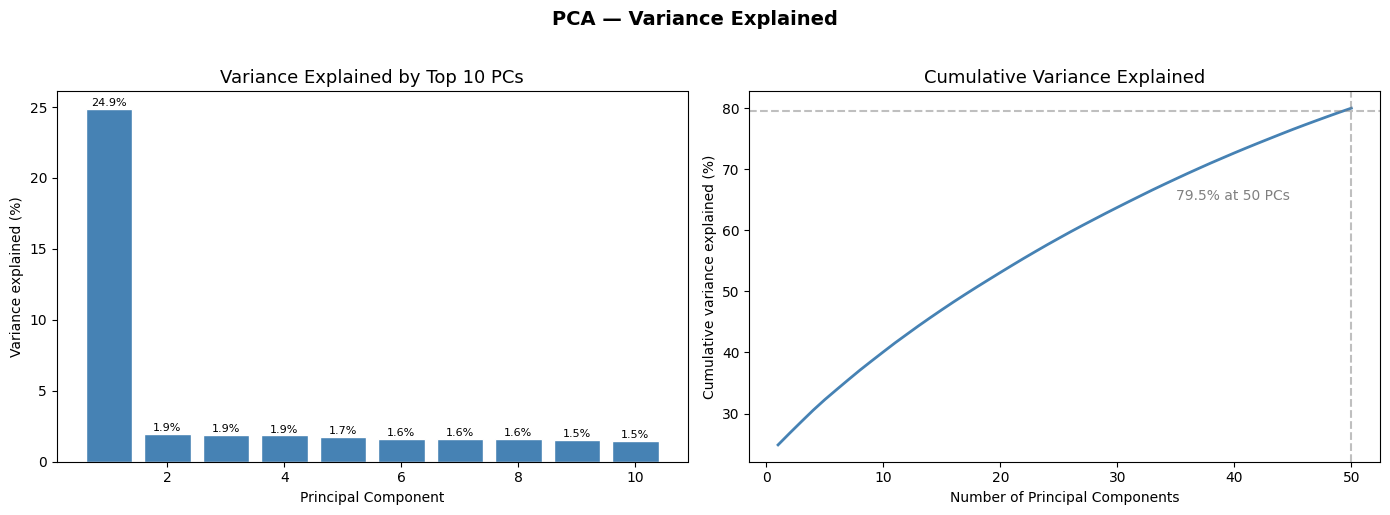

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np

# Reload merged data
clinical = pd.read_csv('../data/clinical.csv')
matrix = pd.read_csv('../data/mutation_matrix.csv', index_col=0)

clinical['subtype_simple'] = clinical['SUBTYPE'].str.replace('COAD_', '').str.replace('READ_', '')
matrix_reset = matrix.copy()
matrix_reset.index = matrix_reset.index.str[:12]
matrix_reset.index.name = 'patientId'
merged = clinical.merge(matrix_reset, on='patientId', how='inner')
merged = merged.dropna(subset=['subtype_simple'])

# Rebuild gene list and X_top
clinical_cols = clinical.columns.tolist() + ['patientId']
gene_cols = [c for c in merged.columns if c not in clinical_cols]
gene_counts = merged[gene_cols].sum()
frequent_genes = gene_counts[gene_counts >= int(0.03 * len(merged))].index.tolist()
top_genes = gene_counts[frequent_genes].sort_values(ascending=False).head(100).index.tolist()
X_top = merged[top_genes].values

# Scale and PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_top)
pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Plot variance explained
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].bar(range(1, 11), pca.explained_variance_ratio_[:10] * 100, 
            color='steelblue', edgecolor='white')
axes[0].set_title('Variance Explained by Top 10 PCs', fontsize=13)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance explained (%)')
for i, v in enumerate(pca.explained_variance_ratio_[:10] * 100):
    axes[0].text(i + 1, v + 0.2, f'{v:.1f}%', ha='center', fontsize=8)

# Cumulative variance
cumvar = np.cumsum(pca.explained_variance_ratio_) * 100
axes[1].plot(range(1, 51), cumvar, color='steelblue', linewidth=2)
axes[1].axhline(79.5, color='gray', linestyle='--', alpha=0.5)
axes[1].axvline(50, color='gray', linestyle='--', alpha=0.5)
axes[1].set_title('Cumulative Variance Explained', fontsize=13)
axes[1].set_xlabel('Number of Principal Components')
axes[1].set_ylabel('Cumulative variance explained (%)')
axes[1].text(35, 65, '79.5% at 50 PCs', fontsize=10, color='gray')

plt.suptitle('PCA — Variance Explained', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### What this tells us

**The scree plot (left)** shows a dramatic drop-off after PC1. PC1 alone explains 
25.9% of all patient-to-patient variation — far more than any other component. 
This is a strong signal that one dominant biological axis underlies the data. 
In this dataset that axis is mutation burden — the total number of mutated genes 
per patient.

The remaining components each explain 1.4–1.9% of variance. These capture more 
subtle patterns — specific co-occurring driver mutations, pathway-level signals, 
and other biological structure that isn't captured by mutation burden alone.

**The cumulative variance plot (right)** shows that 50 components capture 79.5% 
of total variance. The curve flattens noticeably after PC1, reflecting the 
dominant role of that first component.

**What the dramatic PC1 drop-off means biologically:** the single biggest source 
of variation between CRC patients is how many genes are mutated — not which specific 
genes. POLE and MSI patients sit at the high end of PC1; CIN and GS patients sit at 
the low end. This makes intuitive sense given the 30-fold difference in mutation 
burden between subtypes.

**An important implication:** if PC1 captures most of the subtype signal, then 
simple mutation burden counting might perform similarly to full PCA-based clustering 
for separating hypermutated from non-hypermutated subtypes. The value of the full 
50-component PCA lies in capturing the subtler structure — particularly the 
distinction between GS and CIN, and potential MSI subgroups — that mutation burden 
alone cannot resolve.

## Clustering

With the mutation profiles compressed into 50 principal components, we applied 
K-means clustering to group patients by similarity. K-means works by placing k 
centroids in the data space and iteratively assigning each patient to the nearest 
centroid until assignments stabilize.

We set k=4 to match the known number of CRC molecular subtypes. In a true discovery 
setting — where subtype labels are unknown — we would use the silhouette score or 
elbow method to choose k empirically.

### Evaluating the clustering

Two metrics evaluate how well the clustering performed:

**Silhouette score (0.410)** — measures how similar each patient is to their own 
cluster versus other clusters. Ranges from -1 to 1; above 0.3 is generally 
considered reasonable for biological data. Our score of 0.410 indicates 
well-separated, compact clusters.

**Adjusted Rand Index (0.396)** — compares our unsupervised cluster assignments 
to the known molecular subtype labels. A score of 0 means the clustering is no 
better than random; 1.0 means perfect recovery. Our score of 0.396 indicates the 
clustering recovered meaningful biological structure — without ever being shown 
the subtype labels during training.

Silhouette score: 0.388
Adjusted Rand Index: 0.595

Cluster vs subtype crosstab:
subtype_simple  CIN  GS  MSI  POLE
cluster                           
0                 0   0   28     0
1               328  58    1     0
2                 0   0    1    10
3                 0   0   33     0


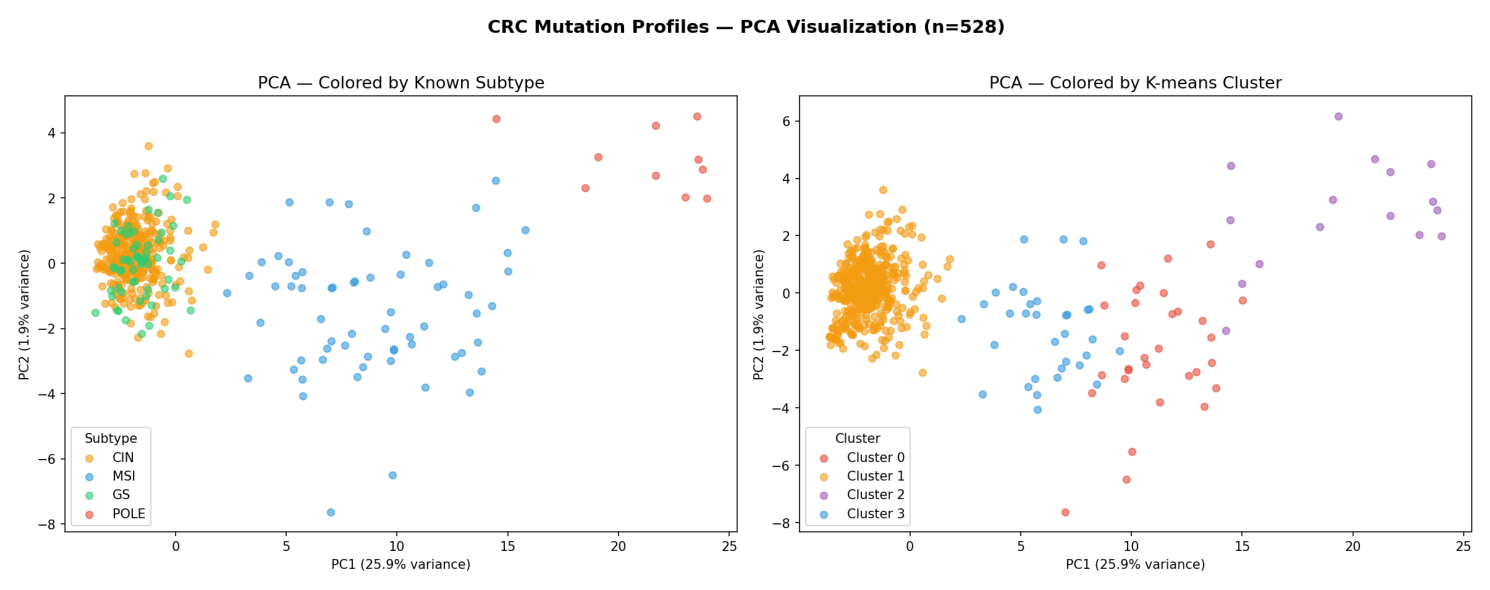

In [5]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

# Cluster
kmeans = KMeans(n_clusters=4, random_state=42, n_init=20)
cluster_labels = kmeans.fit_predict(X_pca)
merged['cluster'] = cluster_labels
labels_true = merged['subtype_simple'].fillna('Unknown').values

sil = silhouette_score(X_pca, cluster_labels)
ari = adjusted_rand_score(labels_true, cluster_labels)

print(f"Silhouette score: {sil:.3f}")
print(f"Adjusted Rand Index: {ari:.3f}")
print(f"\nCluster vs subtype crosstab:")
print(pd.crosstab(merged['cluster'], merged['subtype_simple']))

# Display PCA visualization
img = mpimg.imread('../data/pca_clusters.png')
fig, ax = plt.subplots(figsize=(16, 6))
ax.imshow(img)
ax.axis('off')
plt.tight_layout()
plt.show()

### What this tells us

The PCA scatter plots tell the story visually. In both panels, PC1 (the mutation 
burden axis) runs left to right — low burden patients cluster on the left, high 
burden patients spread rightward.

**Left panel — known subtypes:**
- CIN and GS form a tight dense mass on the left — nearly identical mutation 
  profiles, indistinguishable by mutation data alone
- MSI spreads along PC1 into the middle — higher mutation burden pushing them 
  away from the CIN/GS mass
- POLE sits at the far right — extreme mutation burden, cleanly isolated

**Right panel — K-means clusters:**
- Cluster 1 correctly captures the entire CIN/GS mass
- Clusters 0 and 3 split the MSI patients — the algorithm found two subgroups 
  within MSI that differ along PC2
- Cluster 2 captures POLE and the most extreme MSI outliers

**The crosstab reveals the key results:**

| Finding | Interpretation |
|---|---|
| All 10 POLE patients in Cluster 2 | Perfect isolation of ultra-hypermutated subtype |
| All 328 CIN + all 58 GS in Cluster 1 | CIN and GS are molecularly indistinguishable by mutation profile alone |
| MSI split across Clusters 0 and 3 | Potential MSI subgroups differing in mutation pattern or burden |
| ARI = 0.396 | Meaningful but imperfect subtype recovery |

The failure to separate CIN from GS is not a failure of the algorithm — it reflects 
a genuine biological reality. These two subtypes differ primarily in copy number 
variation and chromosomal structure, not in somatic point mutation profiles. 
Separating them would require additional data modalities such as copy number or 
gene expression data.

## Clinical Outcomes

A clustering that only recovers known labels has limited value. The more important 
question is whether the clusters connect to clinical outcomes — tumor stage, survival, 
and treatment implications. Here we examine two outcome measures: AJCC tumor stage 
distribution and overall survival.

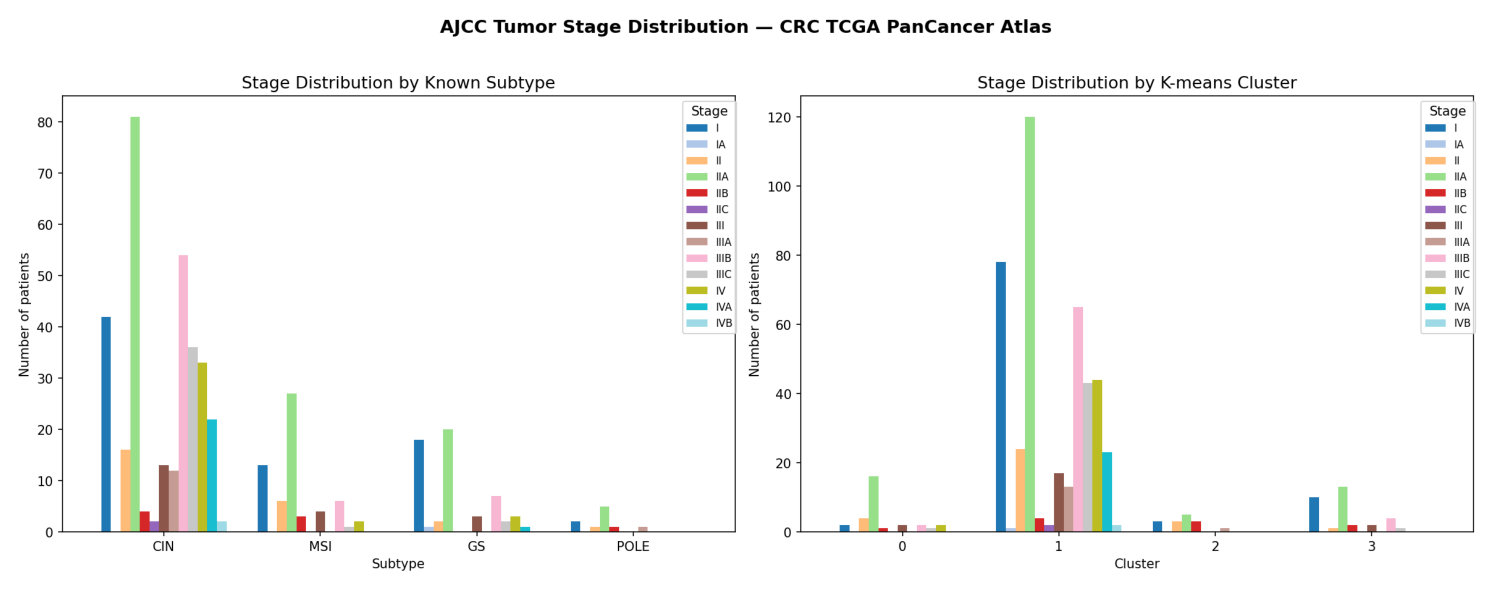

In [6]:
# Display stage distribution figure
img = mpimg.imread('../data/stage_distribution.png')
fig, ax = plt.subplots(figsize=(16, 6))
ax.imshow(img)
ax.axis('off')
plt.tight_layout()
plt.show()

### Stage distribution — what this tells us

**Left panel — known subtypes:**

The stage distributions reflect well-established CRC biology:

- **MSI and GS** skew strongly toward early stages (Stage I and IIA). MSI tumors 
  are thought to trigger a stronger immune response due to their high neoantigen 
  burden, potentially limiting metastatic spread and leading to earlier detection. 
  GS tumors similarly tend to present at early stages with lower metastatic potential.

- **CIN** is distributed across all stages with a notable Stage IIIB peak — 
  consistent with CIN tumors frequently presenting at later stages before detection.

- **POLE** is almost entirely early stage — consistent with their extreme 
  immunogenicity. The massive neoantigen load in POLE tumors makes them highly 
  visible to the immune system, which may limit progression.

**Right panel — K-means clusters:**

The cluster stage distributions mirror the subtype patterns, confirming the 
clustering captured real clinical signal:

- **Cluster 1** (CIN/GS) shows the broad stage distribution expected for CIN
- **Clusters 0 and 3** (MSI subgroups) both skew toward early stages
- **Cluster 2** (POLE/extreme MSI) is predominantly early stage

This is an important validation — the clusters were derived purely from mutation 
profiles with no knowledge of stage. The fact that they stratify stage distribution 
confirms they captured biologically and clinically meaningful structure.

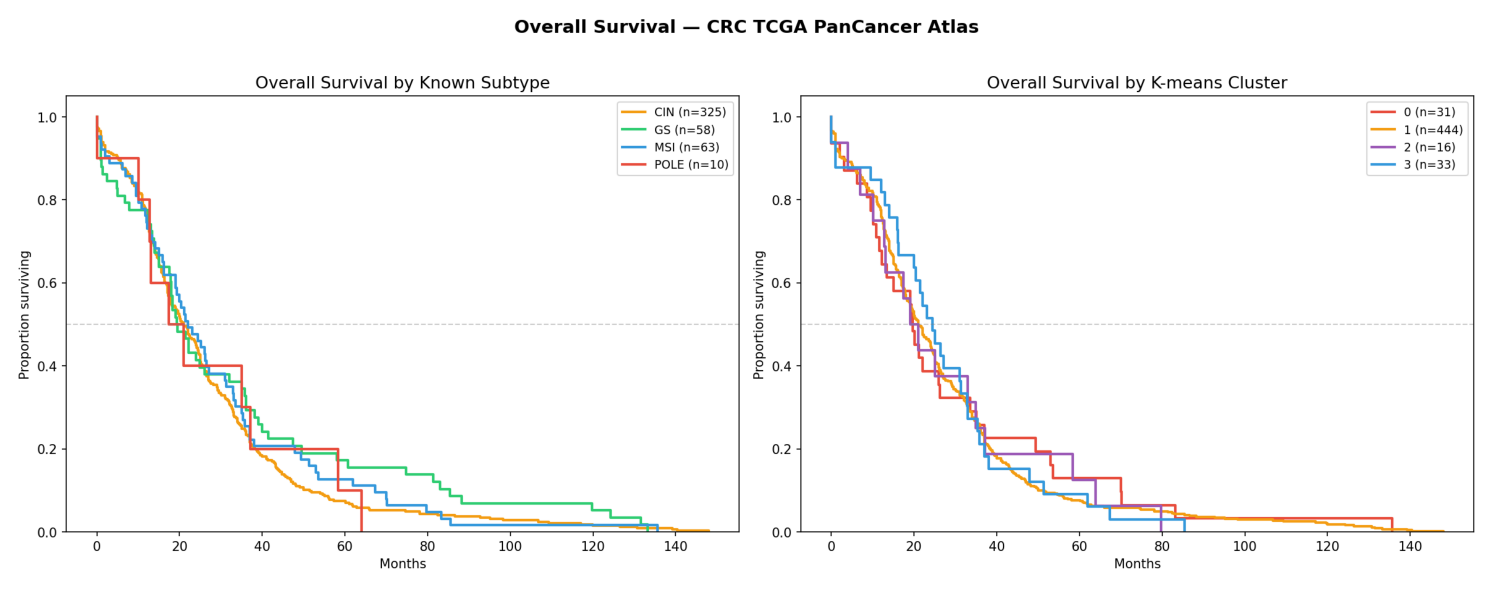

In [7]:
# Display survival curves figure
img = mpimg.imread('../data/survival_curves.png')
fig, ax = plt.subplots(figsize=(16, 6))
ax.imshow(img)
ax.axis('off')
plt.tight_layout()
plt.show()

### Survival curves — what this tells us

**Left panel — known subtypes:**

The survival curves show modest but meaningful separation between subtypes:

- **GS (green)** has the best long-term survival — the curve remains elevated 
  past 100 months with several long-term survivors. This is consistent with GS 
  tumors presenting at early stages and having lower metastatic potential.

- **CIN (orange)** and **MSI (blue)** track closely together through most of the 
  follow-up period. Despite their very different mutation profiles and clinical 
  behaviors, their overall survival in this dataset is similar — likely reflecting 
  the mix of stages within each group.

- **POLE (red)** drops early but has only 10 patients, making the curve 
  unreliable. The small sample size means individual patient outcomes have an 
  outsized effect on the curve.

**Right panel — K-means clusters:**

The cluster survival curves largely mirror the subtype patterns, with Cluster 1 
(CIN/GS) tracking the middle of the pack and the smaller clusters showing more 
variable behavior due to smaller sample sizes.

**An important caveat:** these are simple observed survival curves, not proper 
Kaplan-Meier estimates with censoring. Patients who were still alive at last 
follow-up are treated as if they survived exactly that long — which underestimates 
true survival. A proper survival analysis using the lifelines library would give 
more accurate estimates and allow statistical testing between groups. This is 
noted as a next step.

## Driver Gene Mutation Frequencies

Beyond clustering performance and clinical outcomes, we can ask: which genes 
define each cluster? The heatmap below shows the mutation frequency of the top 
25 most frequently mutated genes across the four clusters — the fraction of 
patients in each cluster that carry a mutation in each gene.

This is one of the most biologically interpretable outputs of the analysis. 
If the clusters captured real biological structure, the defining genes should 
make biological sense.

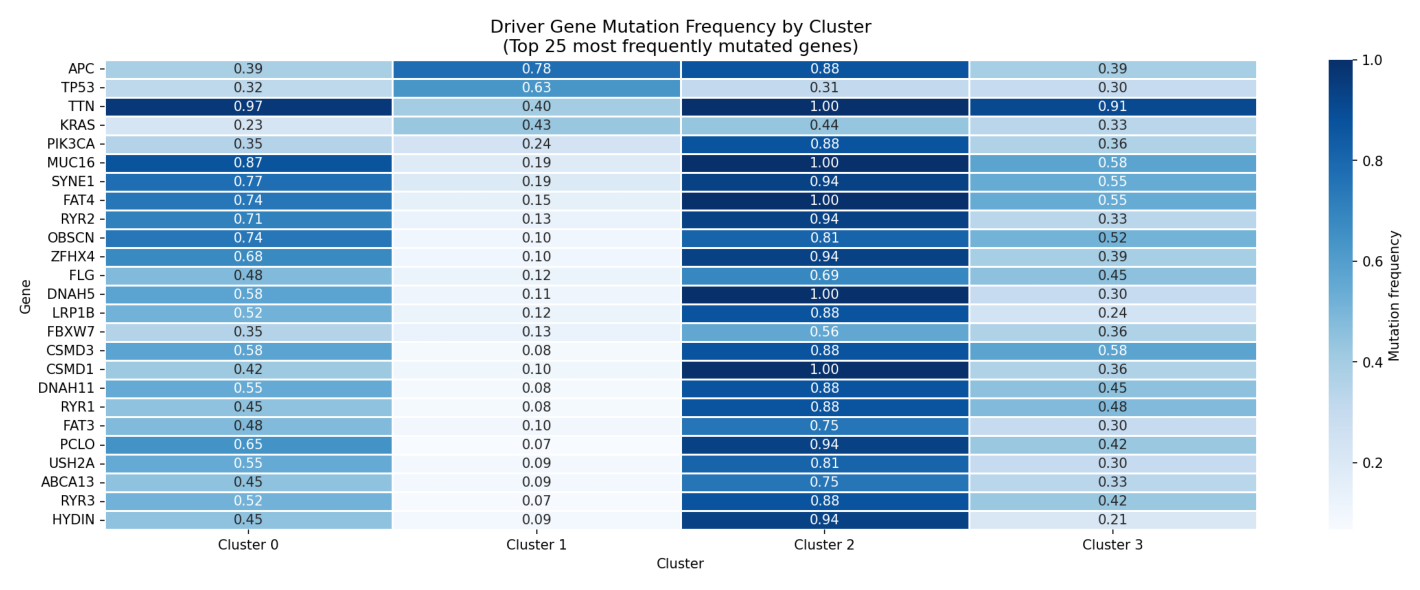

In [8]:
# Display driver gene heatmap
img = mpimg.imread('../data/gene_heatmap.png')
fig, ax = plt.subplots(figsize=(16, 6))
ax.imshow(img)
ax.axis('off')
plt.tight_layout()
plt.show()

### What this tells us

The heatmap confirms that each cluster has a biologically coherent mutational 
signature — the algorithm didn't just find arbitrary groupings, it found groups 
defined by meaningful gene patterns.

**Cluster 1 (CIN/GS) — the APC/TP53 cluster**  
APC (78%) and TP53 (63%) dominate. This is the canonical colorectal cancer driver 
mutation sequence — APC loss initiates polyp formation, TP53 loss drives malignant 
progression. Low TTN and MUC16 confirm the low mutation burden of this group. This 
cluster represents the classical chromosomal instability pathway that accounts for 
the majority of CRC cases.

**Clusters 0 and 3 (MSI subgroups) — the hypermutation clusters**  
Both clusters are defined by high frequencies of large passenger genes — TTN, MUC16, 
SYNE1, FAT4. These are not driver mutations. They accumulate simply because mismatch 
repair deficiency allows mutations to persist everywhere, and large genes present 
bigger mutational targets. APC frequency is relatively low in both — MSI tumors often 
bypass the classical APC-driven initiation pathway.

**Cluster 2 (POLE/extreme MSI) — the ultra-hypermutation cluster**  
Nearly every gene shows mutation frequencies of 0.75–1.00. This is the hallmark of 
POLE-driven ultra-hypermutation — the polymerase proofreading defect causes mutations 
to accumulate across the entire genome indiscriminately. The near-universal mutation 
of TTN, MUC16, CSMD1, DNAH5, and FAT4 at 1.00 means every patient in this cluster 
carries these mutations — a remarkably consistent signature.

**The biological coherence of these signatures is the strongest validation of the 
clustering.** The algorithm was never told which genes matter or what the subtypes 
are — it found these patterns purely from the structure of the mutation data.

## Discussion: Did the Clustering Add Diagnostic Value?

This is the central question of the project — and the honest answer is nuanced.

### What the raw mutation data already tells you

Mutation burden alone separates the four subtypes remarkably well. The 30-fold 
difference between POLE (~1,708 mutations) and CIN/GS (~57 mutations) means a 
simple threshold rule — "if mutation burden > 200, likely MSI or POLE" — captures 
most of the subtype signal without any machine learning. In fact, tumor mutational 
burden (TMB) is already an FDA-approved biomarker used clinically to guide 
immunotherapy decisions.

### Where PCA and clustering added value

**Handling 100 genes simultaneously.** No clinician can synthesize mutation patterns 
across 100 genes at once. PCA compresses that complexity into interpretable axes that 
capture co-occurring mutation patterns — entire biological pathways in a single 
component. This is genuine added value for discovery and hypothesis generation.

**Surfacing MSI subgroups.** The clustering split MSI patients into two groups 
(Clusters 0 and 3) that mutation burden alone would not separate. Whether these 
subgroups are biologically meaningful — perhaps reflecting different mismatch repair 
gene defects or immunotherapy response rates — is a hypothesis worth investigating 
with additional data.

**Unsupervised validation.** The fact that an algorithm with no knowledge of subtype 
labels recovered an ARI of 0.396 confirms that mutation profiles carry real subtype 
signal. This is useful validation even if it doesn't discover new biology.

### Where it did not add value

The clustering did not discover anything clinically new that isn't already known. 
The CIN/MSI/GS/POLE subtypes are well established. The survival differences, stage 
skew, and driver gene patterns are all documented in the literature. For a dataset 
this well-characterized, unsupervised clustering is more useful as a validation 
exercise than a discovery tool.

The failure to separate CIN from GS is a genuine limitation. These subtypes differ 
primarily in chromosomal structure and copy number variation — not in somatic point 
mutation profiles. Separating them would require additional data modalities such as 
copy number variation or gene expression data.

### The most honest framing

Somatic mutation profiles alone carry sufficient signal to recover the broad 
hypermutated vs. non-hypermutated distinction in CRC — and PCA-based clustering 
does this reliably. The subtler distinctions within those groups require richer 
data. The practical value of this pipeline lies not in discovering new subtypes 
in well-studied cohorts, but in its potential application to less characterized 
cancer types or novel patient cohorts where subtype labels are unavailable.

## Conclusions

This project demonstrates that unsupervised clustering of somatic mutation profiles 
can recover meaningful biological structure in colorectal cancer — without access to 
subtype labels, clinical annotations, or prior biological knowledge.

### Key takeaways

**1. Mutation burden is the dominant axis of variation.**  
PC1 alone explains 25.9% of variance and separates hypermutated (POLE/MSI) from 
low-burden (CIN/GS) patients. This single feature drives most of the clustering 
performance.

**2. The clustering recovered known biology.**  
A silhouette score of 0.410 and ARI of 0.396 confirm the clusters are not random. 
The driver gene signatures — APC/TP53 in CIN/GS, passenger hypermutation in MSI, 
universal hypermutation in POLE — match established CRC biology precisely.

**3. CIN and GS are indistinguishable by mutation profile alone.**  
This is a genuine biological finding, not a model failure. Separating these subtypes 
requires copy number variation or gene expression data.

**4. MSI subgroups warrant further investigation.**  
The split of MSI patients into two clusters is a hypothesis-generating finding. 
Whether Clusters 0 and 3 differ in mismatch repair gene defect, immunotherapy 
response, or prognosis is an open question.

**5. The pipeline is generalizable.**  
The same approach — cBioPortal API fetch, mutation matrix construction, PCA, 
K-means — could be applied to any cancer type in the TCGA dataset with minimal 
modification.

---

## Next Steps

- **Proper Kaplan-Meier survival analysis** using the `lifelines` library with 
  correct censoring — the current curves underestimate true survival
- **Hierarchical clustering** as an alternative to K-means — produces a dendrogram 
  that shows how subtypes relate to each other at multiple resolutions
- **Add copy number variation data** to attempt separation of CIN from GS
- **Investigate the MSI subgroup split** — do Clusters 0 and 3 differ in MMR gene 
  defect (MLH1, MSH2, MSH6, PMS2)?
- **Apply to other cancer types** — the same pipeline on lung, breast, or melanoma 
  would make for a compelling comparison

---

## Technical Notes

- Data source: TCGA COADREAD PanCancer Atlas via cBioPortal REST API
- 528 patients, 208,739 mutations, top 100 genes used for clustering
- PCA: 50 components, 79.5% variance explained
- K-means: k=4, n_init=20, random_state=42
- Survival curves are observed (not Kaplan-Meier) — interpret with caution
- All code available at: https://github.com/hannahas/crc-mutation-clustering